# K-Means Clustering Assignment

Q1. K-means on 20 random 1-D points, k taken as input from user<br>
Q2. General k-means for any dataset + compare performance for different parameters + MSE vs iteration graph

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(1)
np.random.seed(1)

## Q1 - K means on 1D data

In [2]:
# generating 20 random points between 0 and 100
data1 = [random.uniform(0, 100) for i in range(20)]
print(data1)

[13.436424411240122, 84.74337369372327, 76.3774618976614, 25.50690257394217, 49.54350870919409, 44.949106478873816, 65.15929727227629, 78.87233511355132, 9.385958677423488, 2.834747652200631, 83.57651039198697, 43.27670679050534, 76.2280082457942, 0.21060533511106927, 44.538719405480144, 72.15400323407826, 22.876222127045263, 94.52706955539223, 90.14274576114836, 3.0589983033553536]


In [3]:
k = int(input("Enter value of k: "))

In [4]:
# basic kmeans for 1D data
def kmeans_1d(data, k, max_iter=100):
    data = np.array(data)
    centroids = random.sample(list(data), k)   # pick k random points as starting centroids
    centroids = np.array(centroids)

    for it in range(max_iter):
        clusters = [[] for i in range(k)]

        # assign each point to nearest centroid
        for point in data:
            dist = [abs(point - c) for c in centroids]
            idx = dist.index(min(dist))
            clusters[idx].append(point)

        new_centroids = []
        for c in clusters:
            if len(c) == 0:
                new_centroids.append(random.choice(data))  # empty cluster, just reinit
            else:
                new_centroids.append(sum(c)/len(c))
        new_centroids = np.array(new_centroids)

        # stop if centroids not changing
        if np.array_equal(new_centroids, centroids):
            break
        centroids = new_centroids

    return clusters, centroids, it+1

In [5]:
clusters, centroids, iters = kmeans_1d(data1, k)

print("took", iters, "iterations\n")
for i in range(k):
    print("cluster", i, "-> centroid =", round(centroids[i],2))
    print(sorted([round(x,2) for x in clusters[i]]))
    print()

took 5 iterations

cluster 0 -> centroid = 20.61
[np.float64(13.44), np.float64(22.88), np.float64(25.51)]

cluster 1 -> centroid = 88.25
[np.float64(83.58), np.float64(84.74), np.float64(90.14), np.float64(94.53)]

cluster 2 -> centroid = 3.87
[np.float64(0.21), np.float64(2.83), np.float64(3.06), np.float64(9.39)]

cluster 3 -> centroid = 73.76
[np.float64(65.16), np.float64(72.15), np.float64(76.23), np.float64(76.38), np.float64(78.87)]

cluster 4 -> centroid = 45.58
[np.float64(43.28), np.float64(44.54), np.float64(44.95), np.float64(49.54)]



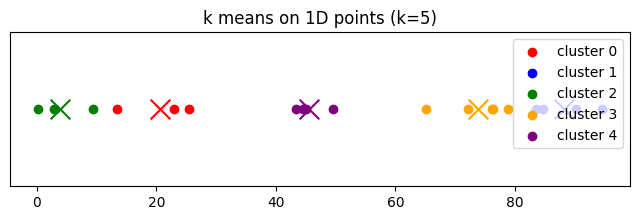

In [6]:
# plotting the clusters on a line
plt.figure(figsize=(8,2))
colors = ['red','blue','green','orange','purple']

for i in range(k):
    plt.scatter(clusters[i], [0]*len(clusters[i]), color=colors[i%5], label=f'cluster {i}')
    plt.scatter(centroids[i], 0, color=colors[i%5], marker='x', s=200)

plt.yticks([])
plt.title("k means on 1D points (k="+str(k)+")")
plt.legend()
plt.show()

## Q2 - General k means (any dataset) + comparing parameters

In [7]:
# this one works for any number of dimensions, and also keeps track of MSE
# every iteration so we can plot it later

def kmeans(data, k, max_iter=100, seed=None):
    data = np.array(data, dtype=float)
    if data.ndim == 1:
        data = data.reshape(-1,1)

    n = data.shape[0]
    rng = np.random.RandomState(seed)
    idx = rng.choice(n, k, replace=False)
    centroids = data[idx].copy()

    mse_list = []

    for it in range(max_iter):
        # distance of every point from every centroid
        dists = np.zeros((n, k))
        for j in range(k):
            dists[:,j] = np.sum((data - centroids[j])**2, axis=1)

        labels = np.argmin(dists, axis=1)

        # mse for this iteration
        mse = np.mean(np.min(dists, axis=1))
        mse_list.append(mse)

        # update centroids
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            pts = data[labels==j]
            if len(pts)==0:
                new_centroids[j] = centroids[j]
            else:
                new_centroids[j] = pts.mean(axis=0)

        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids

    return labels, centroids, mse_list

Using a small made-up dataset here (3 blobs of 2D points). You can replace this with `np.loadtxt("yourfile.csv")` or read a csv with pandas if you have your own data.

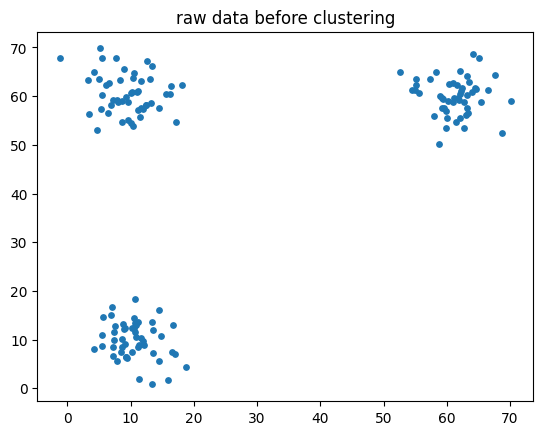

In [8]:
# making a simple dataset with 3 groups of points so clustering actually makes sense
def make_data():
    g1 = np.random.normal(loc=[10,10], scale=4, size=(50,2))
    g2 = np.random.normal(loc=[60,60], scale=4, size=(50,2))
    g3 = np.random.normal(loc=[10,60], scale=4, size=(50,2))
    return np.vstack([g1,g2,g3])

data2 = make_data()

plt.scatter(data2[:,0], data2[:,1], s=15)
plt.title("raw data before clustering")
plt.show()

converged in 2 iterations
final mse = 27.89580230965696


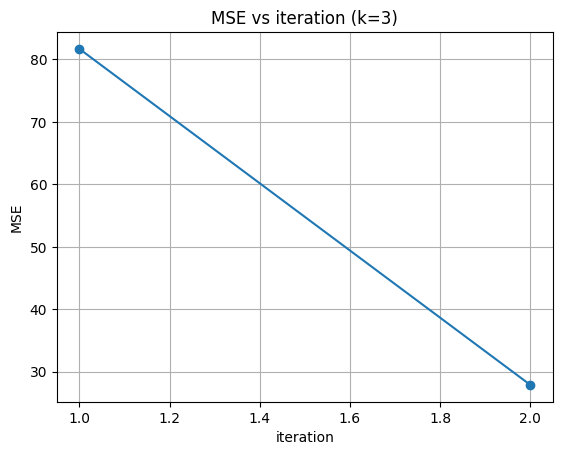

In [9]:
# run kmeans once with k=3 and plot MSE per iteration
labels, centroids, mse_list = kmeans(data2, k=3, seed=0)

print("converged in", len(mse_list), "iterations")
print("final mse =", mse_list[-1])

plt.plot(range(1,len(mse_list)+1), mse_list, marker='o')
plt.title("MSE vs iteration (k=3)")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

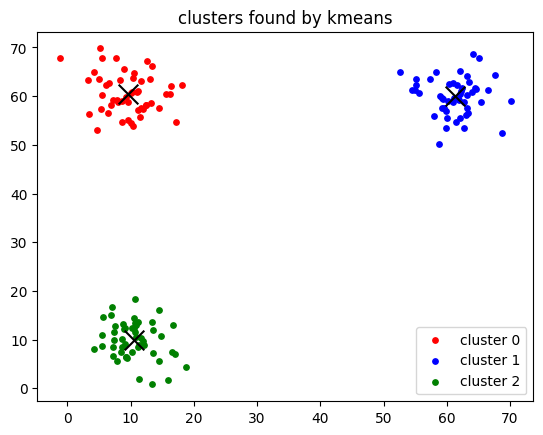

In [10]:
# plotting the actual clusters we got
colors = ['red','blue','green','orange','purple']
for j in range(3):
    pts = data2[labels==j]
    plt.scatter(pts[:,0], pts[:,1], color=colors[j], s=15, label=f'cluster {j}')
plt.scatter(centroids[:,0], centroids[:,1], color='black', marker='x', s=200)
plt.legend()
plt.title("clusters found by kmeans")
plt.show()

### Comparing different values of k

Now trying k = 2,3,4,5 and seeing how MSE changes. Ran each one with 3 different seeds and averaged, since kmeans results depend a bit on where the centroids start.

In [11]:
k_vals = [2,3,4,5]
seeds = [0,1,2]

all_results = {}
for k in k_vals:
    runs = []
    for s in seeds:
        _, _, mse_list = kmeans(data2, k, seed=s)
        runs.append(mse_list)
    all_results[k] = runs

# print avg final mse for each k
for k in k_vals:
    final_vals = [r[-1] for r in all_results[k]]
    print("k =", k, " avg final mse =", round(np.mean(final_vals),3))

k = 2  avg final mse = 454.519
k = 3  avg final mse = 175.377
k = 4  avg final mse = 172.179
k = 5  avg final mse = 170.062


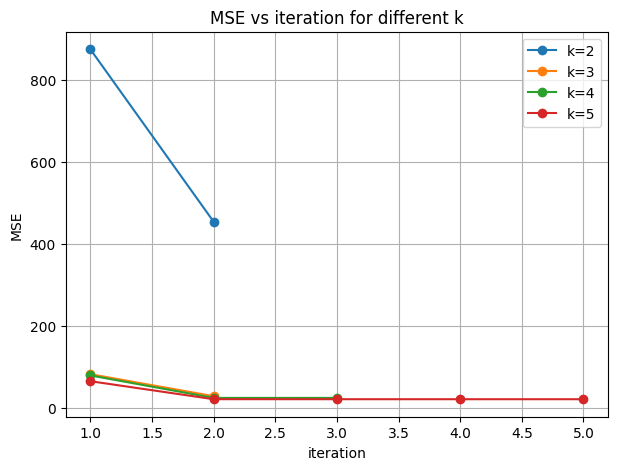

In [12]:
# plotting mse-per-iteration for each k (just using seed 0 run for comparison)
plt.figure(figsize=(7,5))
for k in k_vals:
    mse_list = all_results[k][0]
    plt.plot(range(1,len(mse_list)+1), mse_list, marker='o', label=f'k={k}')

plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("MSE vs iteration for different k")
plt.legend()
plt.grid(True)
plt.show()

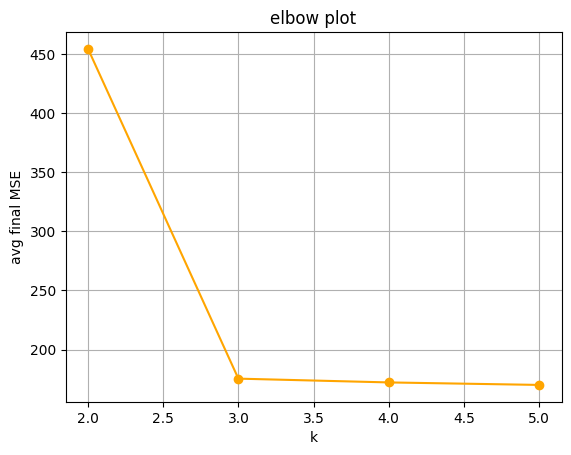

In [13]:
# elbow plot - avg final mse vs k
avg_mse = [np.mean([r[-1] for r in all_results[k]]) for k in k_vals]

plt.plot(k_vals, avg_mse, marker='o', color='orange')
plt.xlabel("k")
plt.ylabel("avg final MSE")
plt.title("elbow plot")
plt.grid(True)
plt.show()

**Observations:**
- MSE drops fast in the first 2-3 iterations then flattens out, that's basically convergence.
- MSE keeps going down as k increases (makes sense, more clusters = smaller distances), but after k=3 the drop isn't that big anymore. So k=3 looks like a decent choice here (matches the 3 groups we made the data with).
- Different seeds can give slightly different MSE for the same k, since kmeans depends on where it starts. Averaging over a few runs helps get a fairer comparison.